In [50]:
!pip install -q timesfm

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from timesfm import (
    TimesFM_2p5_200M_torch,
    ForecastConfig
)

In [52]:
df = pd.read_csv("ETTh1.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [53]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nInfo:")
print(df.info())

Shape: (17420, 8)

Columns:
['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

Missing Values:
date    0
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    17420 non-null  datetime64[ns]
 1   HUFL    17420 non-null  float64       
 2   HULL    17420 non-null  float64       
 3   MUFL    17420 non-null  float64       
 4   MULL    17420 non-null  float64       
 5   LUFL    17420 non-null  float64       
 6   LULL    17420 non-null  float64       
 7   OT      17420 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 1.1 MB
None


In [54]:
df.describe()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,2017-06-28 21:30:00,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
min,2016-07-01 00:00:00,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,2016-12-29 10:45:00,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,2017-06-28 21:30:00,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,2017-12-27 08:15:00,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,2018-06-26 19:00:00,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000
std,NaN,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946


/tmp/ipykernel_8545/1403544720.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


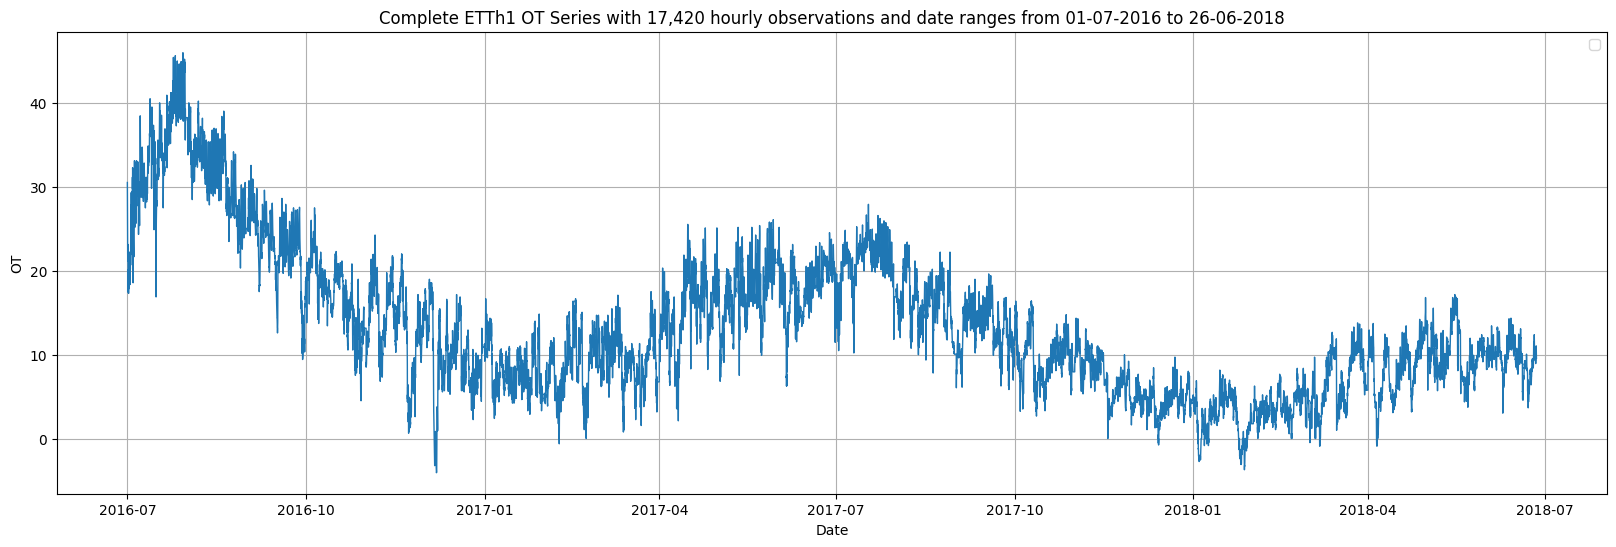

In [55]:
plt.figure(figsize=(20,6))

plt.plot(
    df["date"],
    df["OT"],
    linewidth=1
)
plt.title("Complete ETTh1 OT Series with 17,420 hourly observations and date ranges from 01-07-2016 to 26-06-2018")

plt.xlabel("Date")
plt.ylabel("OT")
plt.legend()
plt.grid(True)
plt.subplot()

plt.show()


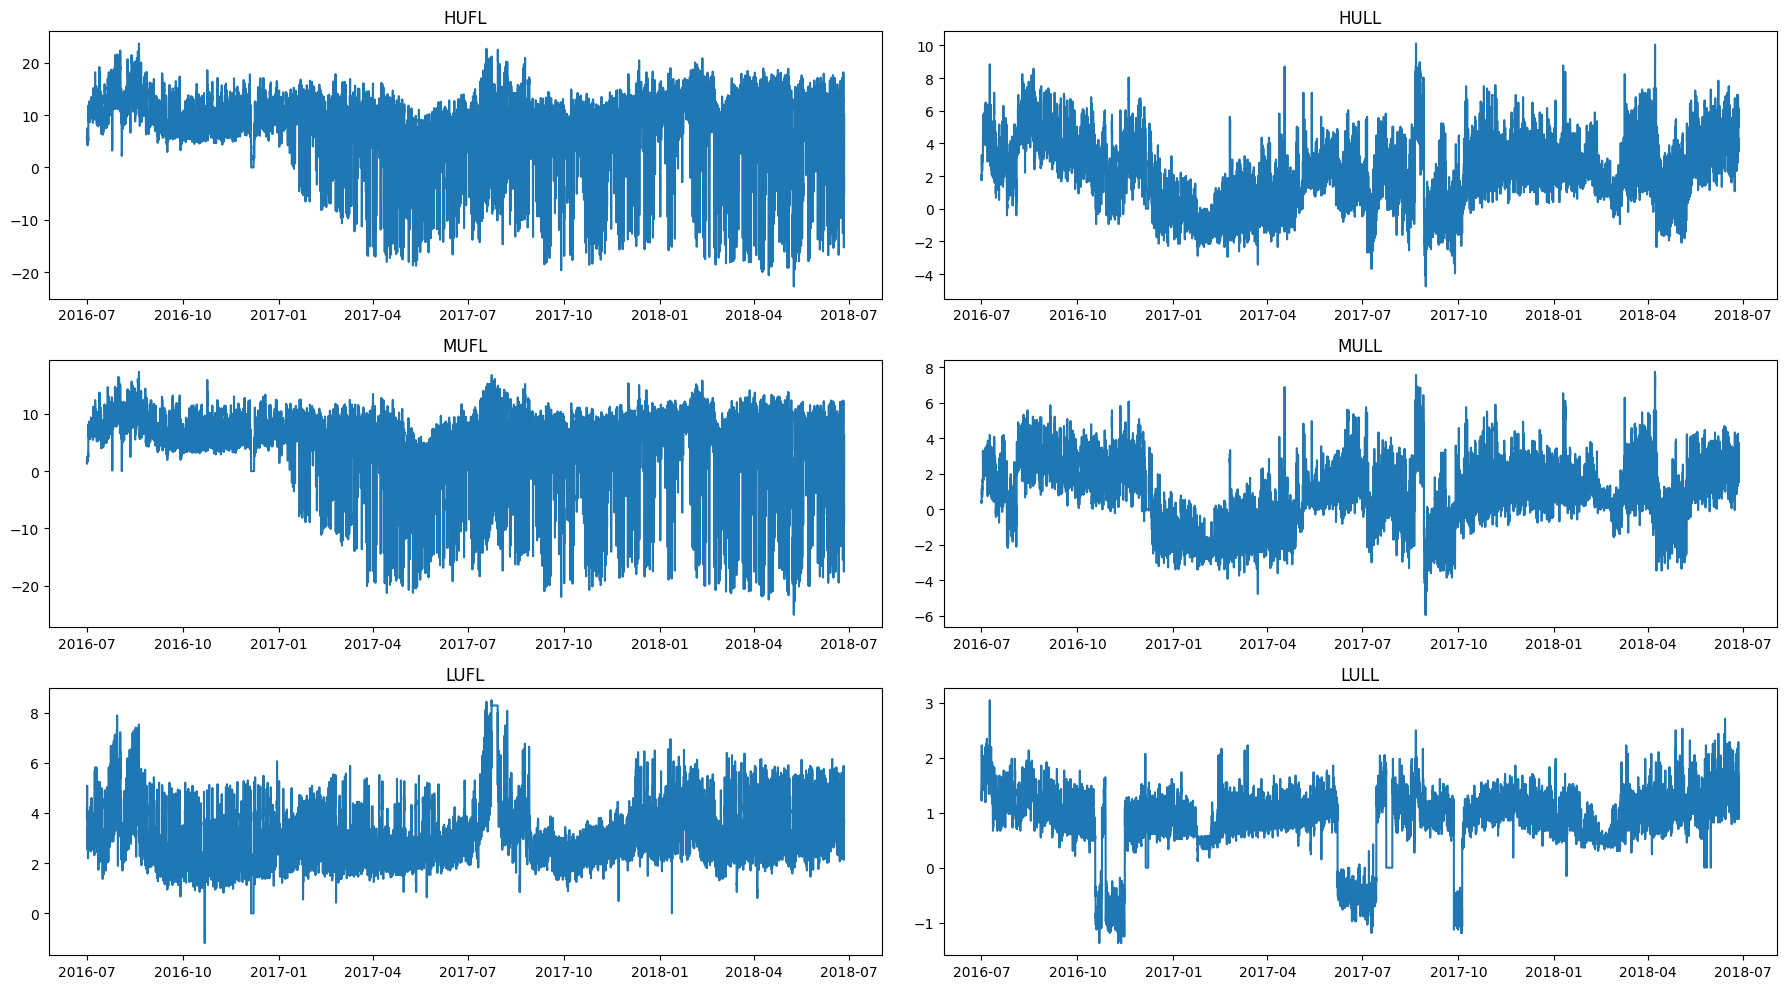

In [56]:
cov_cols_original = [
    "HUFL",
    "HULL",
    "MUFL",
    "MULL",
    "LUFL",
    "LULL"
]

fig, axes = plt.subplots(
    3,
    2,
    figsize=(18,10)
)

axes = axes.flatten()

for i,col in enumerate(cov_cols_original):

    axes[i].plot(
        df["date"],
        df[col]
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

In [57]:
df["hour"] = df["date"].dt.hour

df["dayofweek"] = df["date"].dt.dayofweek

df["month"] = df["date"].dt.month

df["lag24"] = df["OT"].shift(24)

df["lag168"] = df["OT"].shift(168)

df = df.dropna().reset_index(drop=True)

print(df.shape)

(17252, 13)


In [58]:
target_scaler = StandardScaler()

df["OT_scaled"] = target_scaler.fit_transform(
    df[["OT"]]
)

In [59]:
cov_cols = [
    "HUFL",
    "HULL",
    "MUFL",
    "MULL",
    "LUFL",
    "LULL",
    "hour",
    "dayofweek",
    "month",
    "lag24",
    "lag168"
]

cov_scaler = StandardScaler()

df[cov_cols] = cov_scaler.fit_transform(
    df[cov_cols]
)

In [60]:
split_idx = int(len(df)*0.8)

train = df.iloc[:split_idx]

test = df.iloc[split_idx:]

print(train.shape)

print(test.shape)

(13801, 14)
(3451, 14)


In [61]:
print(test.iloc[0])
print(test.iloc[-1])

date         2018-02-03 01:00:00
HUFL                    1.003181
HULL                    1.015556
MUFL                    1.050462
MULL                    0.991767
LUFL                   -0.015652
LULL                   -0.299104
OT                         0.844
hour                   -1.516723
dayofweek               0.997859
month                  -1.302385
lag24                  -1.040458
lag168                 -1.556651
OT_scaled               -1.45458
Name: 13801, dtype: object
date         2018-06-26 19:00:00
HUFL                    0.389379
HULL                    0.653552
MUFL                    0.277771
MULL                     0.38398
LUFL                    0.557537
LULL                    1.031767
OT                         9.567
hour                    1.083948
dayofweek              -0.999712
month                  -0.150968
lag24                  -0.313589
lag168                 -0.770668
OT_scaled              -0.427069
Name: 17251, dtype: object


In [62]:
target_context = train["OT_scaled"].values

print(target_context.shape)

(13801,)


In [63]:
HORIZON = 96

dynamic_covs = {}

for col in cov_cols:

    past = train[col].values

    future = test[col].values[:HORIZON]

    dynamic_covs[col] = [
        np.concatenate(
            [past, future]
        )
    ]

In [64]:
forecast_config = ForecastConfig(
    max_context=len(target_context),
    max_horizon=HORIZON,
    normalize_inputs=False,
    return_backcast=True
)

model = TimesFM_2p5_200M_torch()

model.compile(
    forecast_config=forecast_config
)

outputs, xreg_outputs = model.forecast_with_covariates(
    inputs=[target_context],
    dynamic_numerical_covariates=dynamic_covs,
    xreg_mode="xreg + timesfm"
)

In [65]:
print(type(outputs))

print(type(outputs[0]))

print(outputs[0].shape)

<class 'list'>
<class 'numpy.ndarray'>
(96,)


In [66]:
forecast96 = target_scaler.inverse_transform(
    outputs[0].reshape(-1,1)
).flatten()

actual96 = test["OT"].values[:96]

print(forecast96.shape)
print(actual96.shape)

(96,)
(96,)


In [67]:
mae96 = mean_absolute_error(
    actual96,
    forecast96
)

rmse96 = np.sqrt(
    mean_squared_error(
        actual96,
        forecast96
    )
)

print("MAE :", mae96)
print("RMSE:", rmse96)

MAE : 1.3683307918114516
RMSE: 1.6811739361556903


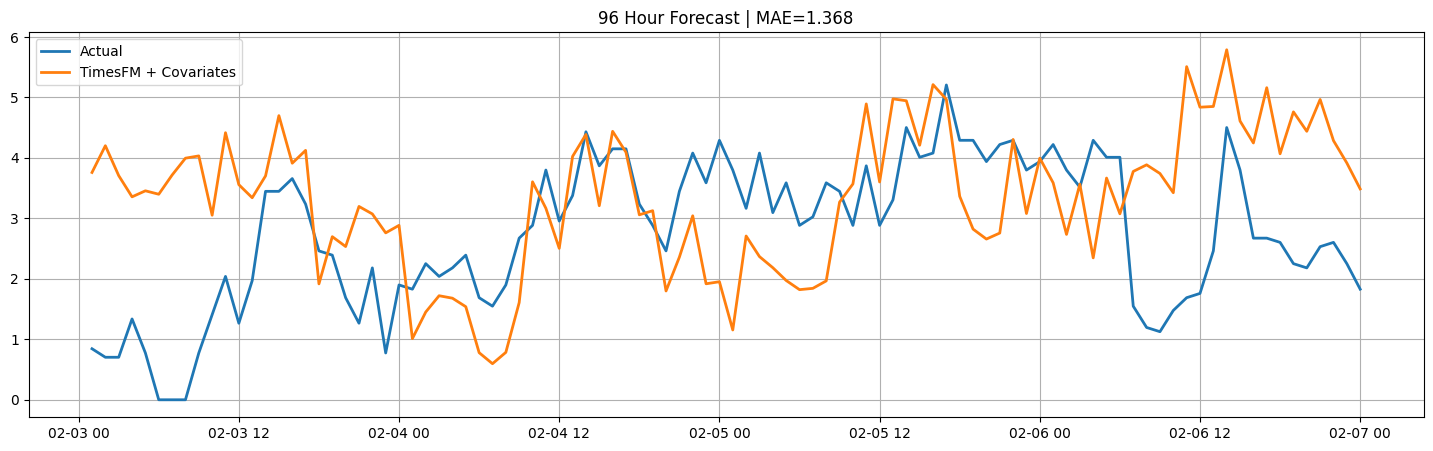

In [68]:
plt.figure(figsize=(18,5))

plt.plot(
    test["date"].iloc[:96],
    actual96,
    label="Actual",
    linewidth=2
)

plt.plot(
    test["date"].iloc[:96],
    forecast96,
    label="TimesFM + Covariates",
    linewidth=2
)

plt.legend()

plt.title(
    f"96 Hour Forecast | MAE={mae96:.3f}"
)

plt.grid(True)

plt.show()

In [69]:
HORIZON = 336

dynamic_covs = {}

for col in cov_cols:

    past = train[col].values

    future = test[col].values[:HORIZON]

    dynamic_covs[col] = [
        np.concatenate(
            [past, future]
        )
    ]

forecast_config = ForecastConfig(
    max_context=len(target_context),
    max_horizon=HORIZON,
    normalize_inputs=False,
    return_backcast=True
)

model336 = TimesFM_2p5_200M_torch()

model336.compile(
    forecast_config=forecast_config
)

outputs336, xreg336 = model336.forecast_with_covariates(
    inputs=[target_context],
    dynamic_numerical_covariates=dynamic_covs,
    xreg_mode="xreg + timesfm"
)

In [70]:
forecast336 = target_scaler.inverse_transform(
    outputs336[0].reshape(-1,1)
).flatten()

actual336 = test["OT"].values[:336]

mae336 = mean_absolute_error(
    actual336,
    forecast336
)

rmse336 = np.sqrt(
    mean_squared_error(
        actual336,
        forecast336
    )
)

print("MAE :", mae336)
print("RMSE:", rmse336)

MAE : 1.552275214024077
RMSE: 1.866297817180195


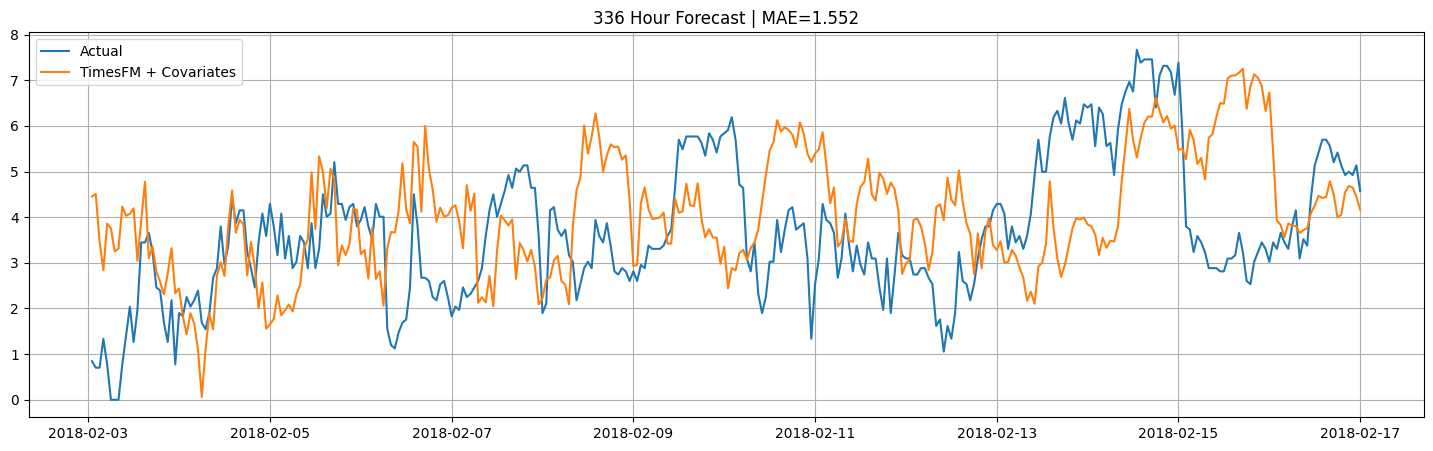

In [71]:
plt.figure(figsize=(18,5))

plt.plot(
    test["date"].iloc[:336],
    actual336,
    label="Actual"
)

plt.plot(
    test["date"].iloc[:336],
    forecast336,
    label="TimesFM + Covariates"
)

plt.legend()

plt.title(
    f"336 Hour Forecast | MAE={mae336:.3f}"
)

plt.grid(True)

plt.show()

In [72]:
HORIZON = 576

dynamic_covs = {}

for col in cov_cols:

    past = train[col].values

    future = test[col].values[:HORIZON]

    dynamic_covs[col] = [
        np.concatenate(
            [past, future]
        )
    ]

forecast_config = ForecastConfig(
    max_context=len(target_context),
    max_horizon=HORIZON,
    normalize_inputs=False,
    return_backcast=True
)

model576 = TimesFM_2p5_200M_torch()

model576.compile(
    forecast_config=forecast_config
)

outputs576, xreg576 = model576.forecast_with_covariates(
    inputs=[target_context],
    dynamic_numerical_covariates=dynamic_covs,
    xreg_mode="xreg + timesfm"
)

In [73]:
forecast576 = target_scaler.inverse_transform(
    outputs576[0].reshape(-1,1)
).flatten()

actual576 = test["OT"].values[:576]

mae576 = mean_absolute_error(
    actual576,
    forecast576
)

rmse576 = np.sqrt(
    mean_squared_error(
        actual576,
        forecast576
    )
)

print("MAE :", mae576)
print("RMSE:", rmse576)

MAE : 1.4627473810968437
RMSE: 1.7896453684589664


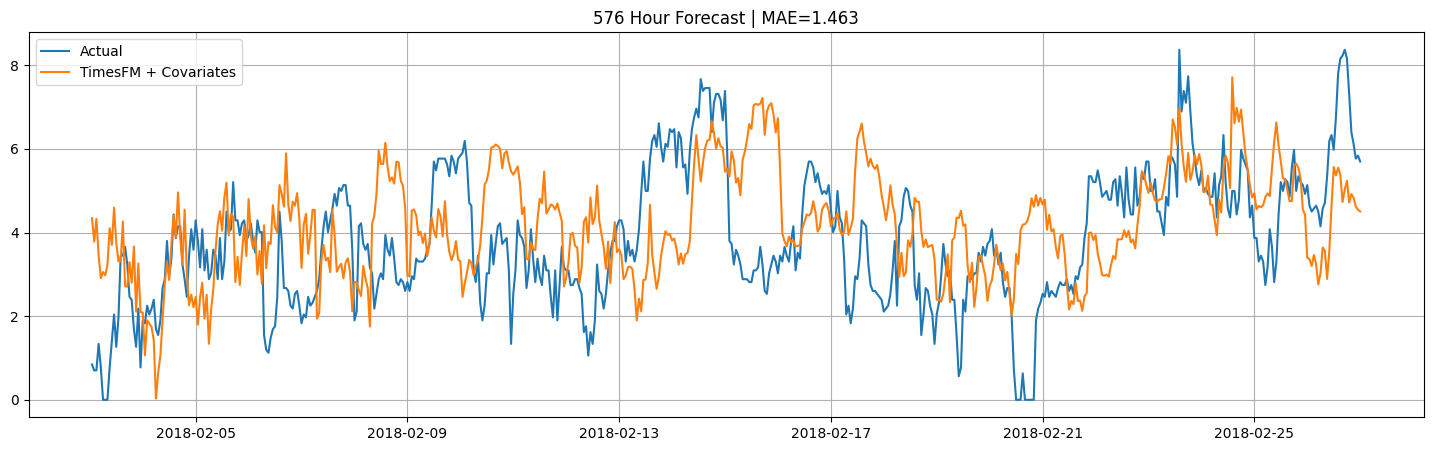

In [74]:
plt.figure(figsize=(18,5))

plt.plot(
    test["date"].iloc[:576],
    actual576,
    label="Actual"
)

plt.plot(
    test["date"].iloc[:576],
    forecast576,
    label="TimesFM + Covariates"
)

plt.legend()

plt.title(
    f"576 Hour Forecast | MAE={mae576:.3f}"
)

plt.grid(True)

plt.show()

In [77]:
HORIZON = len(test)

HORIZON_ALIGNED = ((HORIZON + 31)//32)*32

MAX_CONTEXT = 16384 - HORIZON_ALIGNED

MAX_CONTEXT = (MAX_CONTEXT // 32) * 32

print(MAX_CONTEXT)

12928


In [78]:
target_context = train["OT_scaled"].values[-MAX_CONTEXT:]

In [86]:
past = train[col].values[-MAX_CONTEXT:]

In [96]:
dynamic_covs = {}

for col in cov_cols:

    # Context part
    past = train[col].values[-MAX_CONTEXT:]

    # Future part
    future = test[col].values[:HORIZON]

    # Concatenate
    dynamic_covs[col] = [
        np.concatenate(
            [past, future]
        )
    ]

print(dynamic_covs.keys())

dict_keys(['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'hour', 'dayofweek', 'month', 'lag24', 'lag168'])


In [84]:
forecast_config = ForecastConfig(
    max_context=MAX_CONTEXT,
    max_horizon=HORIZON,
    normalize_inputs=False,
    return_backcast=True
)

model_full = TimesFM_2p5_200M_torch()

model_full.compile(
    forecast_config=forecast_config
)

In [85]:
outputs_full, xreg_full = model_full.forecast_with_covariates(
    inputs=[target_context],
    dynamic_numerical_covariates=dynamic_covs,
    xreg_mode="xreg + timesfm"
)

print(outputs_full[0].shape)

(3451,)


In [87]:
forecast_full = target_scaler.inverse_transform(
    outputs_full[0].reshape(-1,1)
).flatten()

actual_full = test["OT"].values[:HORIZON]

print(forecast_full.shape)
print(actual_full.shape)
mae_full = mean_absolute_error(
    actual_full,
    forecast_full
)

rmse_full = np.sqrt(
    mean_squared_error(
        actual_full,
        forecast_full
    )
)

print("MAE :", mae_full)
print("RMSE:", rmse_full)

(3451,)
(3451,)
MAE : 1.6306120352658957
RMSE: 2.1258885603344657


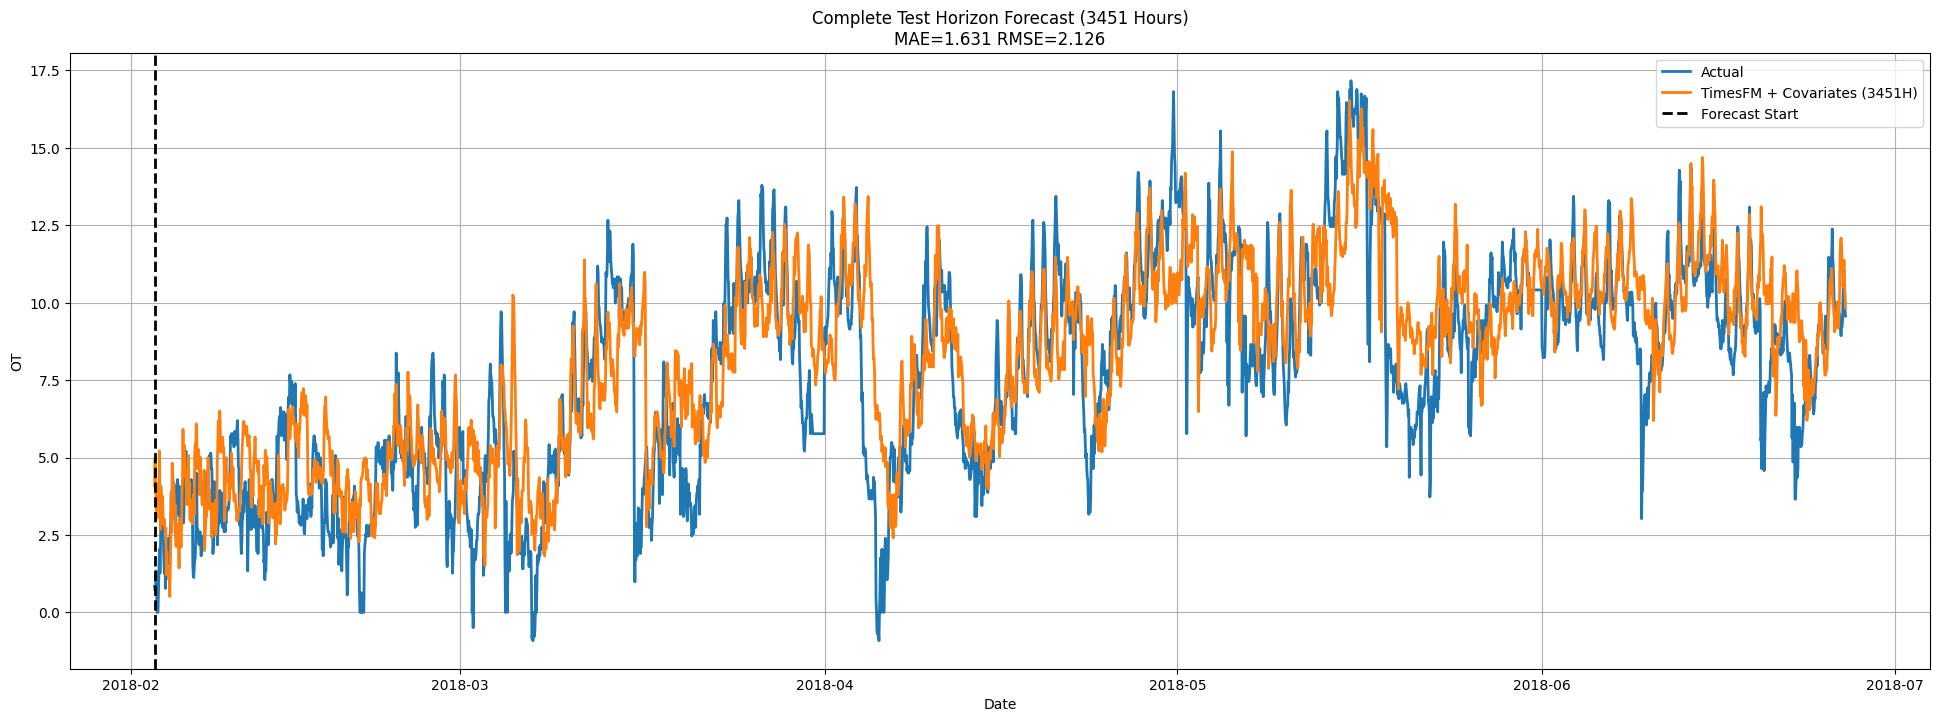

In [88]:
plt.figure(figsize=(24,8))

plt.plot(
    test["date"],
    actual_full,
    label="Actual",
    linewidth=2
)

plt.plot(
    test["date"],
    forecast_full,
    label="TimesFM + Covariates (3451H)",
    linewidth=2
)

plt.axvline(
    test["date"].iloc[0],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Forecast Start"
)

plt.title(
    f"Complete Test Horizon Forecast ({HORIZON} Hours)\nMAE={mae_full:.3f} RMSE={rmse_full:.3f}"
)

plt.xlabel("Date")
plt.ylabel("OT")

plt.legend()

plt.grid(True)

plt.show()

In [89]:
results = pd.DataFrame({
    "Horizon":[96,336,576,3451],
    "MAE":[mae96,mae336,mae576,mae_full],
    "RMSE":[rmse96,rmse336,rmse576,rmse_full]
})

results = results.sort_values("Horizon")

results

,Horizon,MAE,RMSE
0,96,1.368331,1.681174
1,336,1.552275,1.866298
2,576,1.462747,1.789645
3,3451,1.630612,2.125889


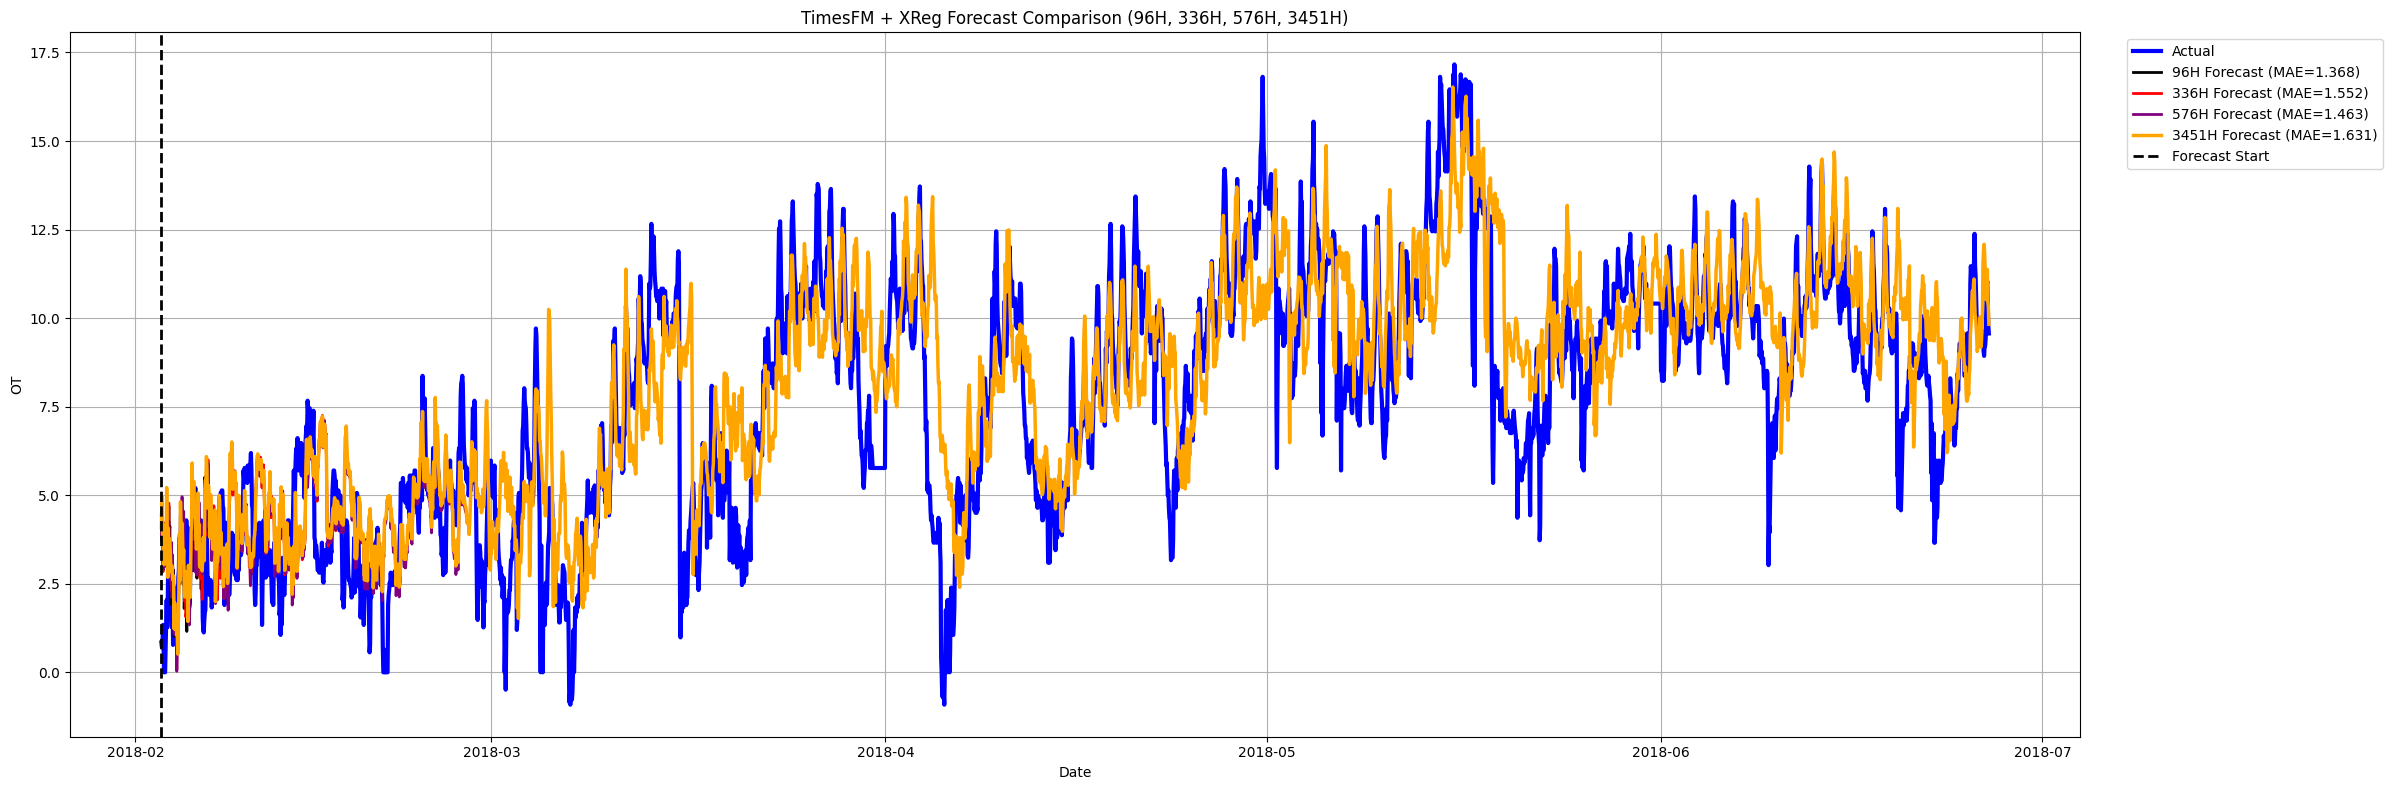

In [95]:
plt.figure(figsize=(24,8))

# Actual Data

plt.plot(
    test["date"],
    actual_full,
    color="blue",
    linewidth=3,
    label="Actual"
)

# 96H Forecast

plt.plot(
    test["date"].iloc[:96],
    forecast96,
    color="black",
    linewidth=2,
    label=f"96H Forecast (MAE={mae96:.3f})"
)

# 336H Forecast

plt.plot(
    test["date"].iloc[:336],
    forecast336,
    color="red",
    linewidth=2,
    label=f"336H Forecast (MAE={mae336:.3f})"
)

# 576H Forecast

plt.plot(
    test["date"].iloc[:576],
    forecast576,
    color="purple",
    linewidth=2,
    label=f"576H Forecast (MAE={mae576:.3f})"
)

# Full Test Horizon Forecast (3451H)

plt.plot(
    test["date"],
    forecast_full,
    color="orange",
    linewidth=2.5,
    label=f"3451H Forecast (MAE={mae_full:.3f})"
)

plt.axvline(
    test["date"].iloc[0],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Forecast Start"
)

plt.title(
    "TimesFM + XReg Forecast Comparison (96H, 336H, 576H, 3451H)"
)

plt.xlabel("Date")
plt.ylabel("OT")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

plt.show()